## Panel f — Novel CoreNet Tfh markers (leave-one-out)

For NR3C1, Tfh cells areidentified using `corenet_markers - {'NR3C1'}`.  
For POU2F2, Tfh cells are identified using `corenet_markers - {'POU2F2'}`.  
The plotted gene is never used to define which cells are "Tfh".

## Setup

In [2]:
import os
import math
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, false_discovery_control

## Config — edit paths for your environment

In [3]:
# Inputs
# Inputs
adata_h5ad   = "adata_moran_tonsil.h5ad"
corenet_grn  = "/ix/djishnu/Alisa/Tfh/testing_for_github/Data/From_Taiji/processed_Taiji/GRN_genes_all_sets_152.csv"
corenet_ppi  = "/ix/djishnu/Alisa/Tfh/testing_for_github/Data/PPS_1_significant_gene_list.csv"
rna_fc_csv   = "../../Data/bulk_RNA/rna_earlyvsGC_log2FC.csv"


# Outputs
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

## Load data and build the CoreNet Tfh marker set

In [4]:
adata = sc.read_h5ad(adata_h5ad)
adata.var_names_make_unique()

# CoreNet gene list: union of GRN + PPI, intersected with GC-up genes,
# with POU2F2 toggled in via symmetric difference (matches original notebook).
taiji = pd.read_csv(corenet_grn)
ppi   = pd.read_csv(corenet_ppi)
ppi_taiji = set(taiji['Genes']).union(set(ppi['Genes']))

rna_df = pd.read_csv(rna_fc_csv)
gc_up_genes = set(rna_df.loc[rna_df['LogChange'] > 0, 'Genes'])

ppi_taiji = (ppi_taiji & gc_up_genes) ^ {'POU2F2'}
corenet_markers = set(ppi_taiji)  # snapshot for leave-one-out
print(f"CoreNet markers: {len(corenet_markers)}")

CoreNet markers: 148


/ihome/djishnu/alo90/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## Preprocess and identify Tfh cells

In [5]:
# Normalize and log-transform if data looks like raw counts
if adata.X.max() > 50:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

# Replace NaN with 0
if sp.issparse(adata.X):
    adata.X = np.nan_to_num(adata.X.toarray(), nan=0.0)
else:
    adata.X = np.nan_to_num(adata.X, nan=0.0)

def get_expr(adata, gene):
    x = adata[:, gene].X
    if hasattr(x, 'todense'):
        return np.asarray(x.todense()).flatten()
    return np.asarray(x).flatten()

cd4_expr = get_expr(adata, 'CD4') > 0

def identify_tfh(marker_set, score_name='Tfh_score'):
    """Score cells against `marker_set`, threshold at the 85th percentile,
    require >=15 markers expressed and CD4+. Returns a boolean array of
    length adata.n_obs."""
    available = [g for g in marker_set if g in adata.var_names]
    sc.tl.score_genes(adata, gene_list=available, score_name=score_name)
    threshold = np.percentile(adata.obs[score_name], 85)
    marker_expr = pd.DataFrame(
        {g: get_expr(adata, g) > 0 for g in available},
        index=adata.obs_names
    )
    n_markers = marker_expr.sum(axis=1).values
    return (
        (adata.obs[score_name].values >= threshold) &
        (n_markers >= min(15, len(available))) &
        cd4_expr
    )

# Default Tfh labeling: full CoreNet marker set (used by panels d and e)
adata.obs['is_Tfh'] = identify_tfh(corenet_markers)

# Subset to CD4+ cells
adata_cd4 = adata[cd4_expr].copy()
print(f"CD4+ cells: {adata_cd4.n_obs}")
print(f"Tfh cells:  {adata_cd4.obs['is_Tfh'].sum()}")

/ihome/djishnu/alo90/.local/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/ihome/djishnu/alo90/.local/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:385: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


CD4+ cells: 1375
Tfh cells:  103


/ihome/djishnu/alo90/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## Bar-plot helper

In [6]:
def plot_marker_bars(plot_genes, panel_name, leave_one_out=False, ymin=1):
    """Bar plot of mean expression in Tfh vs Non-Tfh CD4 cells for each gene,
    with Mann-Whitney significance stars and FC printed in the title.

    leave_one_out=False (panels d, e): use the precomputed adata.obs['is_Tfh']
      labeling (built from the full CoreNet marker set).

    leave_one_out=True (panel f): for each gene, re-identify Tfh cells using
      corenet_markers MINUS that gene, so the gene being plotted is never
      part of the marker set used to define which cells are 'Tfh'.
    """
    plot_genes = [g for g in plot_genes if g in adata_cd4.var_names]
    default_tfh_mask = adata_cd4.obs['is_Tfh'].values.astype(bool)

    ncols = max(1, min(4, len(plot_genes)))
    nrows = math.ceil(len(plot_genes) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for i, gene in enumerate(plot_genes):

        if leave_one_out:
            loo_markers = corenet_markers - {gene}
            tfh_mask_full = identify_tfh(loo_markers, score_name='_tfh_score_loo')
            tfh_mask = tfh_mask_full[cd4_expr]  # align with adata_cd4
        else:
            tfh_mask = default_tfh_mask

        expr = get_expr(adata_cd4, gene)
        tfh_expr     = expr[tfh_mask]
        non_tfh_expr = expr[~tfh_mask]

        fc      = tfh_expr.mean() / (non_tfh_expr.mean() + 1e-9)
        _, pval = mannwhitneyu(tfh_expr, non_tfh_expr, alternative='two-sided')
        pval    = false_discovery_control(pval)
        means   = [tfh_expr.mean(),     non_tfh_expr.mean()]
        sems    = [tfh_expr.std()     / np.sqrt(len(tfh_expr)),
                   non_tfh_expr.std() / np.sqrt(len(non_tfh_expr))]

        if   pval < 0.0001: stars = '****'
        elif pval < 0.001:  stars = '***'
        elif pval < 0.01:   stars = '**'
        elif pval < 0.05:   stars = '*'
        else:               stars = 'ns'

        axes[i].bar(['Tfh', 'Non-Tfh CD4'], means, yerr=sems,
                    color=['#F8766D', '#00BFC4'], edgecolor='black', capsize=4)

        ymax = max(means) + max(sems)
        ytop = ymax * 1.1
        axes[i].plot([0, 0, 1, 1], [ymax*1.05, ytop, ytop, ymax*1.05],
                     color='black', lw=1)
        axes[i].text(0.5, ytop, stars, ha='center', va='bottom', fontsize=16)
        axes[i].set_title(f'{gene}\nFC={fc:.2f}', fontsize=14, fontweight='bold')
        axes[i].set_ylabel('Mean expression', fontsize=14)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', labelsize=12)
        axes[i].tick_params(axis='y', labelsize=12)
        axes[i].spines['right'].set_visible(False)
        axes[i].spines['top'].set_visible(False)
        if ymin is not None:
            axes[i].set_ylim(bottom=ymin)

    for j in range(len(plot_genes), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{panel_name}.pdf'), bbox_inches='tight')
    plt.savefig(os.path.join(output_dir, f'{panel_name}.png'), dpi=150, bbox_inches='tight')
    plt.show()

## Panel d — Known non-Tfh markers

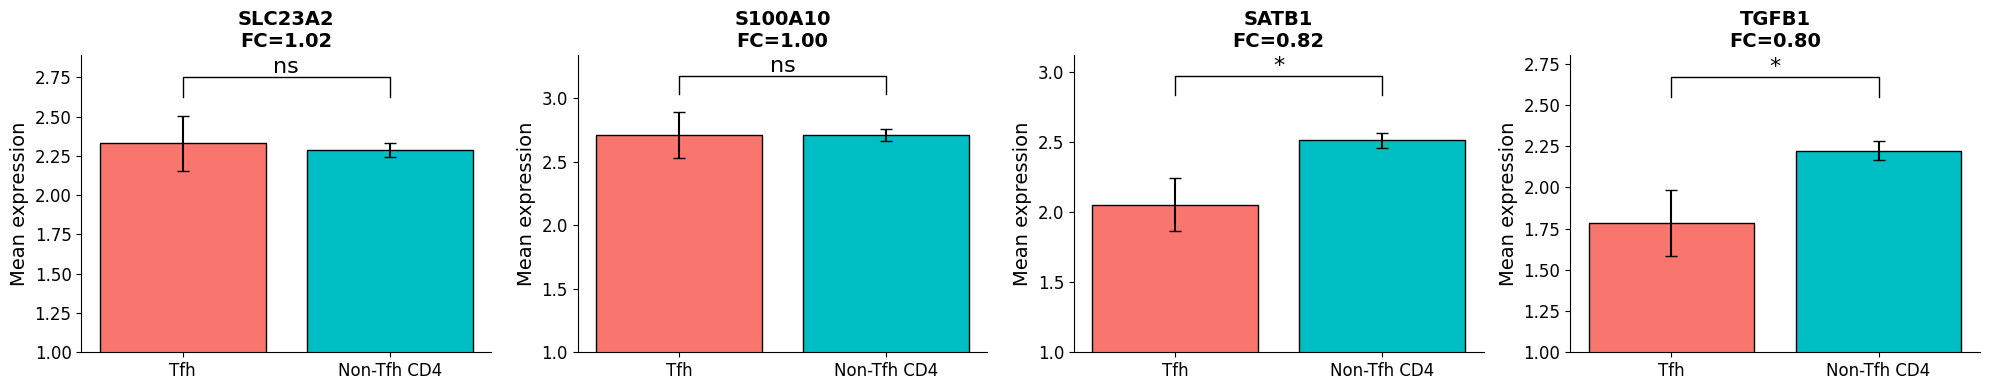

In [7]:
plot_marker_bars(['SLC23A2', 'S100A10', 'SATB1', 'TGFB1'],
                 panel_name='panel_d_non_tfh_markers')

## Panel e — Known Tfh markers

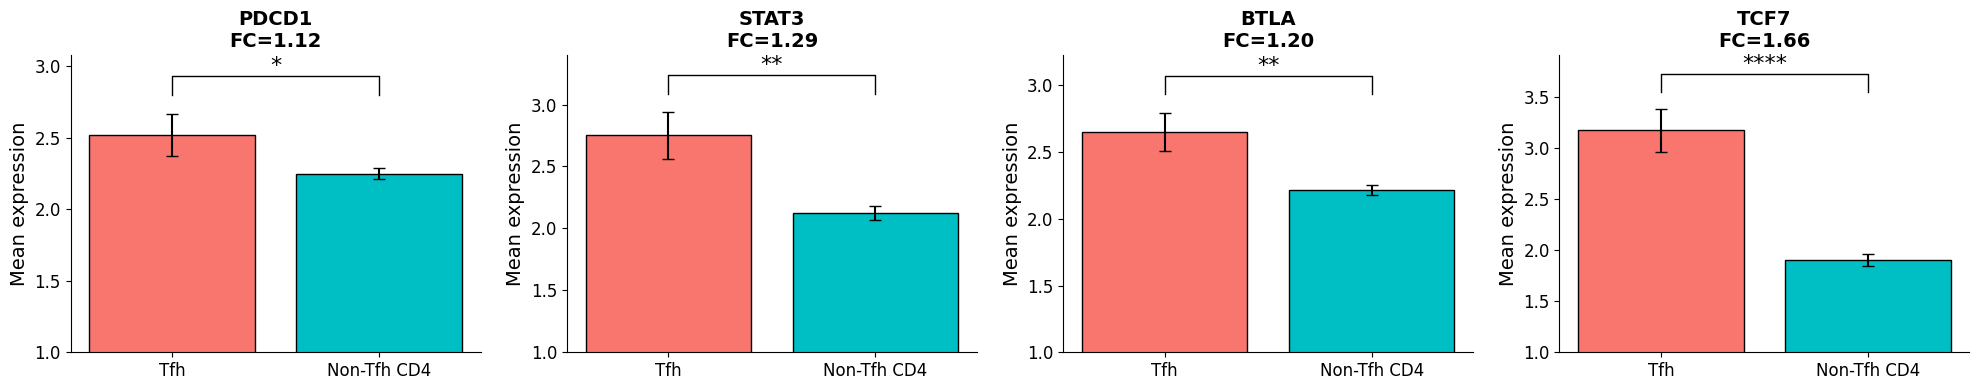

In [8]:
plot_marker_bars(['PDCD1', 'STAT3', 'BTLA', 'TCF7'],
                 panel_name='panel_e_tfh_markers')

## Panel f — Novel CoreNet Tfh markers

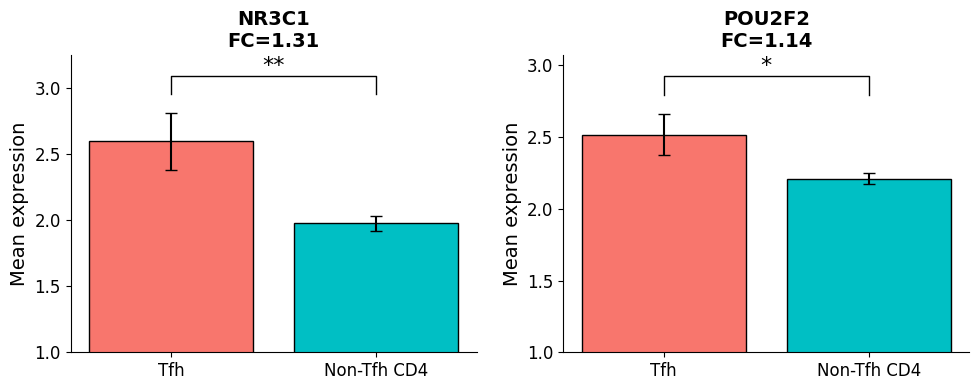

In [9]:
plot_marker_bars(['NR3C1', 'POU2F2'],
                 panel_name='panel_f_corenet_markers',
                 leave_one_out=True)